# Batch of 10 randomized scenes vs. the best generalized U-Net

This notebook creates 10 independently domain-randomized scenes with `minimum_objects = 5` and evaluates all 10 together using `General_Attempt_Using_2nd_Overfit/best_UNet.pt`. It uses the environment's normal object count, size, rotation, position, color, camera, and lighting randomization.

The final section renders separate 2×5 grids containing all 10 RGB environments, all 10 model-predicted heatmaps, and all 10 environment-generated ground-truth heatmaps.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from scipy.ndimage import maximum_filter
from scipy.optimize import linear_sum_assignment


def find_environment_directory():
    current_directory = Path.cwd().resolve()
    candidates = [
        current_directory,
        current_directory.parent,
        current_directory / "CODE" / "Enviornment",
        *[parent / "CODE" / "Enviornment" for parent in current_directory.parents],
    ]
    for candidate in candidates:
        if (candidate / "enviornment.py").is_file() and (candidate / "xml_models" / "world.xml").is_file():
            return candidate
    raise RuntimeError("Could not find CODE/Enviornment from the current notebook directory")


ENVIRONMENT_DIRECTORY = find_environment_directory()
if str(ENVIRONMENT_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(ENVIRONMENT_DIRECTORY))

from Model.UNet.unet import UNet
from Model.UNet.tmp.UNET_MODEL_OVERFIT_2ND_ROUND.UNetV2Constants import UNetV2Constants
from enviornment import Enviornment
from enviornment_randomizer import Enviornment_Randomizer
from randomization_constants import Randomization_Constants

WORLD_XML_FILE = ENVIRONMENT_DIRECTORY / "xml_models" / "world.xml"
BEST_CHECKPOINT_FILE = (
    ENVIRONMENT_DIRECTORY
    / "Model"
    / "UNet"
    / "tmp"
    / "General_Attempt_Using_2nd_Overfit"
    / "best_UNet.pt"
)
assert BEST_CHECKPOINT_FILE.is_file(), f"Best generalized checkpoint not found: {BEST_CHECKPOINT_FILE}"

print(f"Environment directory: {ENVIRONMENT_DIRECTORY}")
print(f"Checkpoint: {BEST_CHECKPOINT_FILE}")

Environment directory: /Users/aadibhatia/self-feeder-env/CODE/Enviornment
Checkpoint: /Users/aadibhatia/self-feeder-env/CODE/Enviornment/Model/UNet/tmp/General_Attempt_Using_2nd_Overfit/best_UNet.pt


## Generate 10 randomized environments

Ten fresh seeds are selected whenever this notebook runs. A printed seed can be reused later to reproduce a particular scene. Placement may leave fewer than five active objects if the randomized objects cannot all fit on the plate.

In [2]:
BATCH_SIZE = 10
model_constants = UNetV2Constants()
seed_generator = np.random.default_rng()
scene_seeds = seed_generator.integers(1_000_000, 10_000_000, size=BATCH_SIZE)
scene_records = []

for scene_index, scene_seed in enumerate(scene_seeds, start=1):
    scene_seed = int(scene_seed)
    randomization_constants = Randomization_Constants()
    randomization_constants.minimum_objects = 5
    enviornment_randomizer = Enviornment_Randomizer()

    env = Enviornment(
        xml_file=str(WORLD_XML_FILE),
        Enviornment_Randomizer=enviornment_randomizer,
        Randomization_Constants=randomization_constants,
        Model_Constants=model_constants,
        starting_seed=scene_seed,
    )
    env.new_scene(seed=scene_seed)

    scene_records.append({
        "seed": scene_seed,
        "rgb": env.observation(),
        "target": env.get_target_heatmap(),
        "active_count": env.get_number_of_active_food_objects(),
    })
    print(
        f"Scene {scene_index:2d}: seed={scene_seed}, "
        f"active foods={scene_records[-1]['active_count']}/"
        f"{randomization_constants.total_food_slots}"
    )

assert len(scene_records) == BATCH_SIZE

Scene  1: seed=2065326, active foods=4/12


Scene  2: seed=4734153, active foods=2/12


Scene  3: seed=4119040, active foods=2/12


Scene  4: seed=1012978, active foods=3/12


Scene  5: seed=9551532, active foods=3/12


Scene  6: seed=6871635, active foods=3/12


Scene  7: seed=2504495, active foods=3/12


Scene  8: seed=2751314, active foods=3/12


Scene  9: seed=7649734, active foods=2/12


Scene 10: seed=7679001, active foods=4/12


## Run one batched `best_UNet.pt` prediction

In [3]:
model = UNet(
    in_channels=3,
    num_classes=1,
    checkpoint_dir=str(BEST_CHECKPOINT_FILE.parent),
    learning_rate=model_constants.learning_rate,
)
model.load_state_dict(
    torch.load(BEST_CHECKPOINT_FILE, map_location=model.device, weights_only=True)
)
model.eval()

rgb_batch = np.stack([record["rgb"] for record in scene_records])
target_heatmaps = np.stack([record["target"] for record in scene_records])

model_input_batch = (
    torch.from_numpy(rgb_batch)
    .permute(0, 3, 1, 2)
    .float()
    / 255.0
)
model_input_batch = F.interpolate(
    model_input_batch,
    size=(model_constants.input_y_dim, model_constants.input_x_dim),
    mode="bilinear",
    align_corners=False,
).to(model.device)

with torch.no_grad():
    prediction_logits = model(model_input_batch)
    predicted_heatmaps = torch.sigmoid(prediction_logits)[:, 0].cpu().numpy()

assert predicted_heatmaps.shape == target_heatmaps.shape
assert predicted_heatmaps.shape == (
    BATCH_SIZE,
    model_constants.output_y_dim,
    model_constants.output_x_dim,
)
assert np.isfinite(predicted_heatmaps).all()

print(f"Model device: {model.device}")
print(f"RGB batch shape: {rgb_batch.shape}")
print(f"Model input batch shape: {tuple(model_input_batch.shape)}")
print(f"Prediction batch shape: {predicted_heatmaps.shape}")
print(f"Target batch shape: {target_heatmaps.shape}")
print(
    f"Prediction range across batch: "
    f"{predicted_heatmaps.min():.6f} to {predicted_heatmaps.max():.6f}"
)

Created UNet on: mps


Model device: mps
RGB batch shape: (10, 1080, 1920, 3)
Model input batch shape: (10, 3, 144, 256)
Prediction batch shape: (10, 144, 256)
Target batch shape: (10, 144, 256)
Prediction range across batch: 0.000000 to 0.948478


## Quantify and render all 10 scenes

For each scene, we select at most one predicted peak per active food object, requiring at least 5% predicted probability. Hungarian assignment matches predictions one-to-one with distinct ground-truth centers. The three grids make the RGB environments, predictions, and labels directly comparable.

Scene  1 | seed=2065326 | targets=4 | peaks=4 | unmatched=0 | mean=2.35px | worst=5.39px
Scene  2 | seed=4734153 | targets=2 | peaks=2 | unmatched=0 | mean=1.21px | worst=1.41px
Scene  3 | seed=4119040 | targets=2 | peaks=2 | unmatched=0 | mean=0.50px | worst=1.00px
Scene  4 | seed=1012978 | targets=3 | peaks=3 | unmatched=0 | mean=0.33px | worst=1.00px
Scene  5 | seed=9551532 | targets=3 | peaks=3 | unmatched=0 | mean=0.33px | worst=1.00px
Scene  6 | seed=6871635 | targets=3 | peaks=3 | unmatched=0 | mean=1.33px | worst=2.00px
Scene  7 | seed=2504495 | targets=3 | peaks=3 | unmatched=0 | mean=0.33px | worst=1.00px
Scene  8 | seed=2751314 | targets=3 | peaks=3 | unmatched=0 | mean=1.80px | worst=2.00px
Scene  9 | seed=7649734 | targets=2 | peaks=2 | unmatched=0 | mean=0.50px | worst=1.00px
Scene 10 | seed=7679001 | targets=4 | peaks=4 | unmatched=0 | mean=1.00px | worst=1.00px


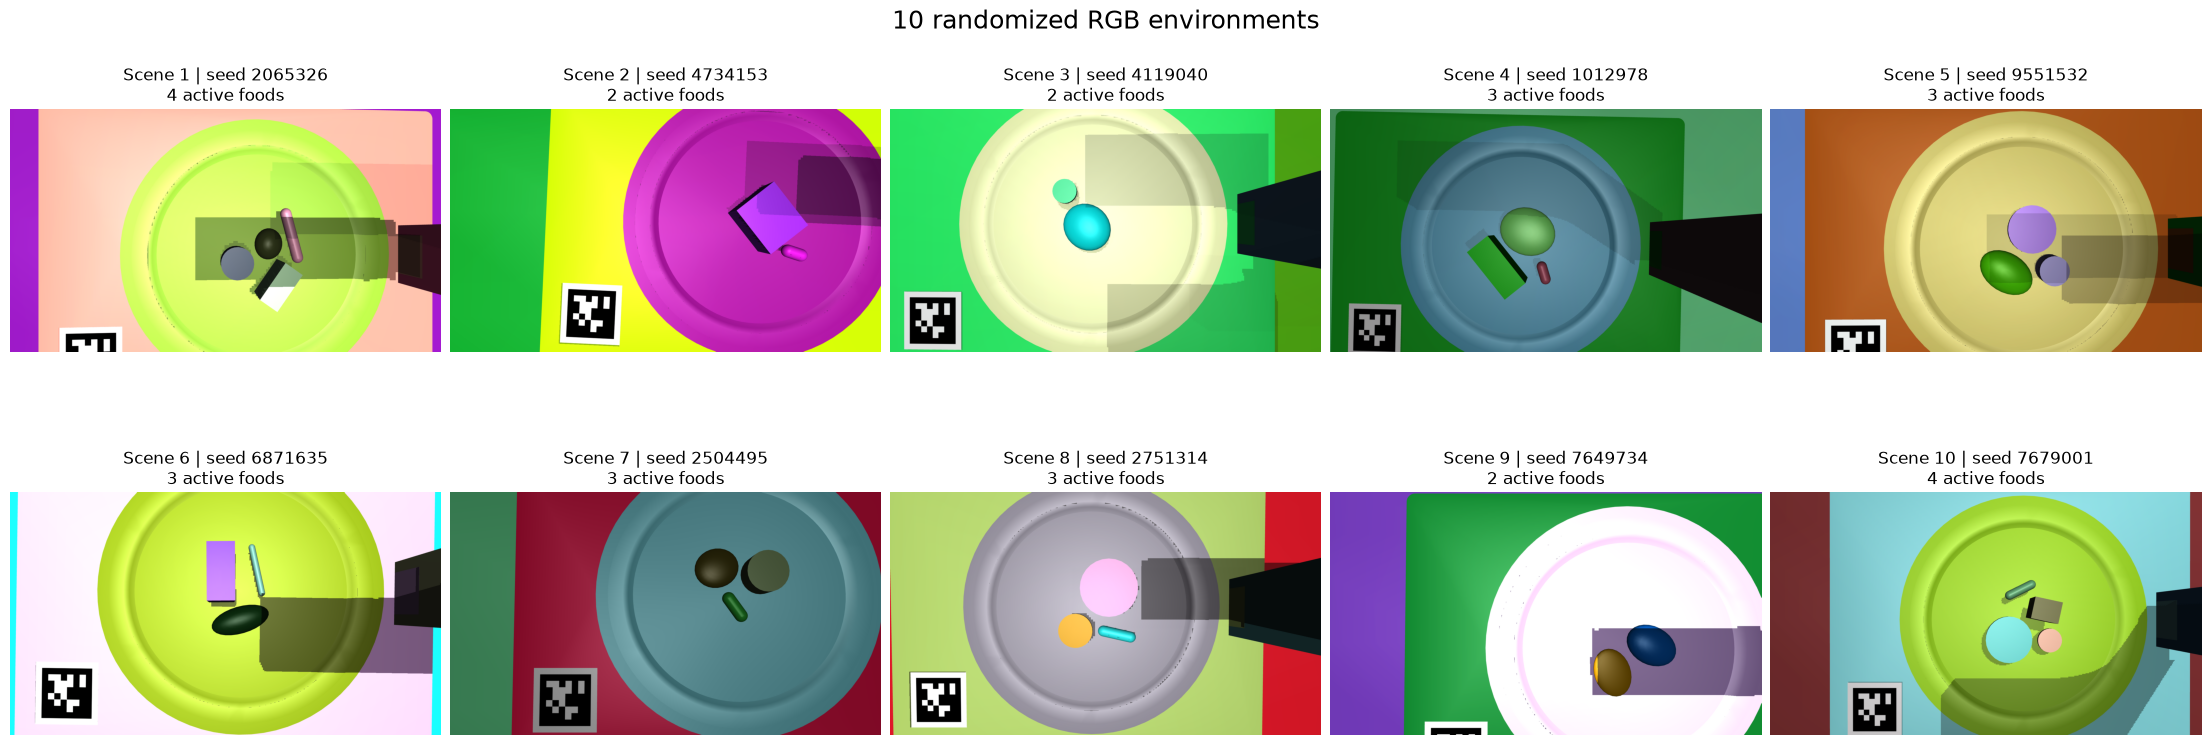

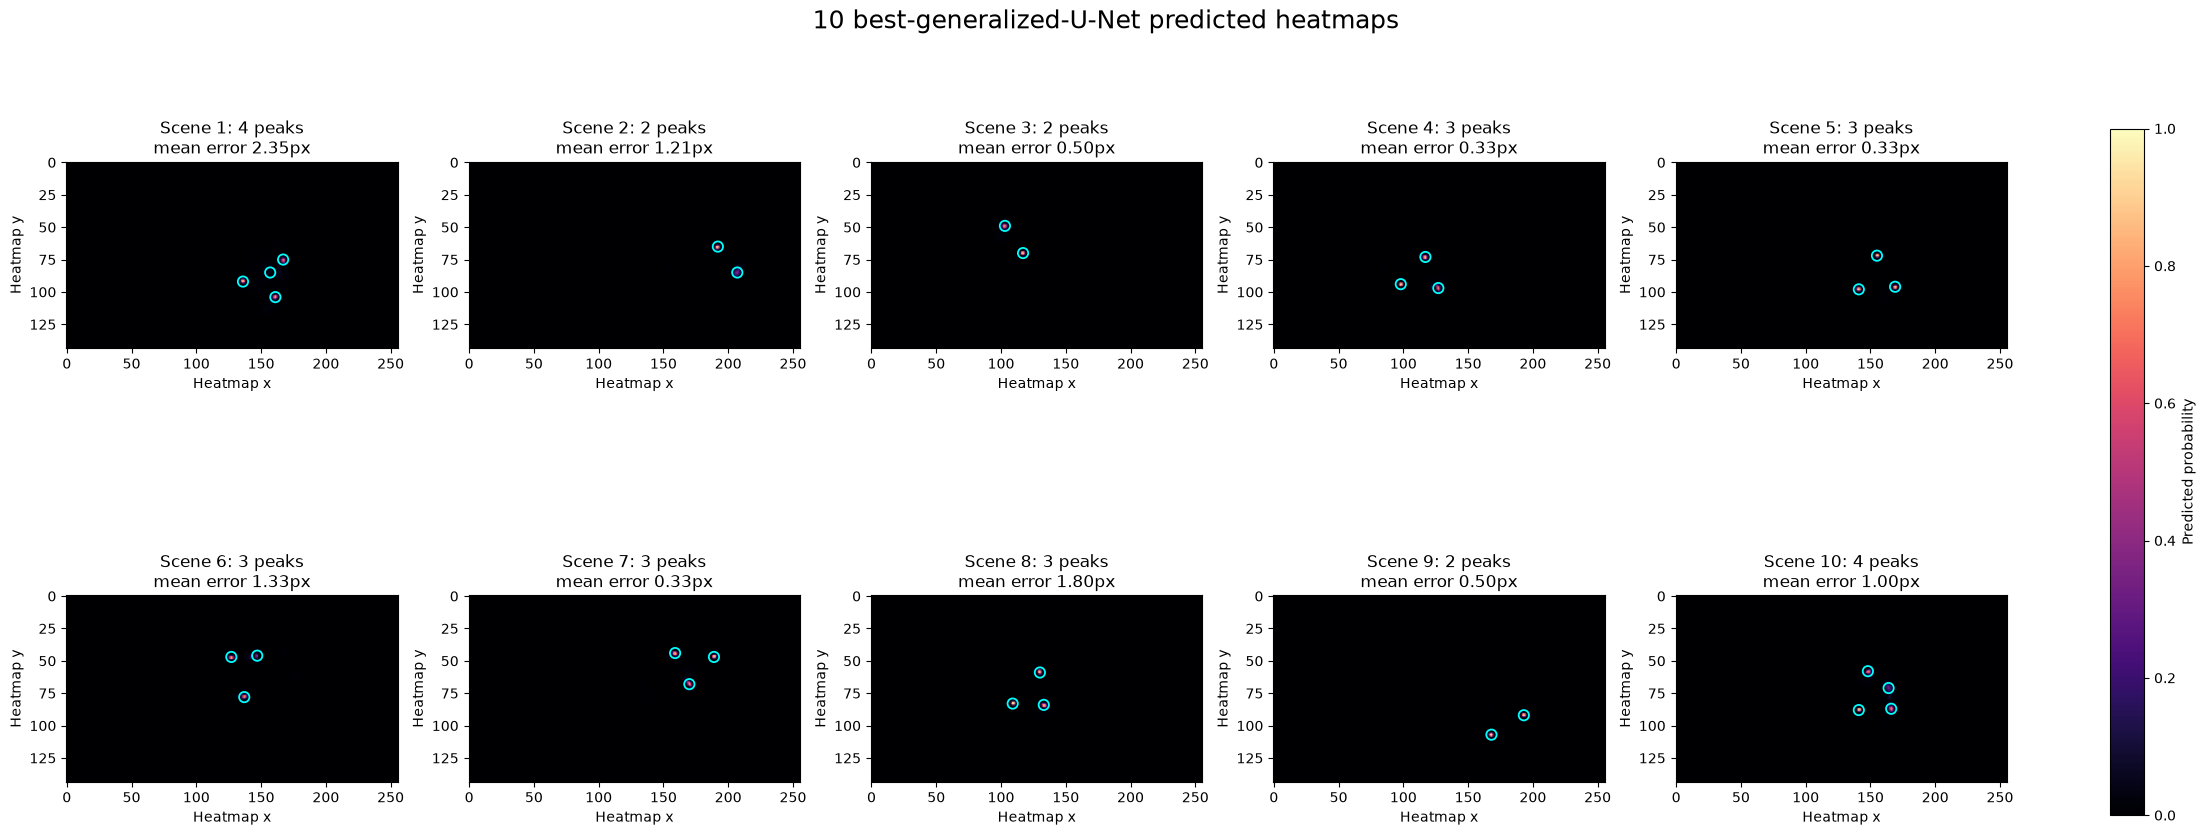

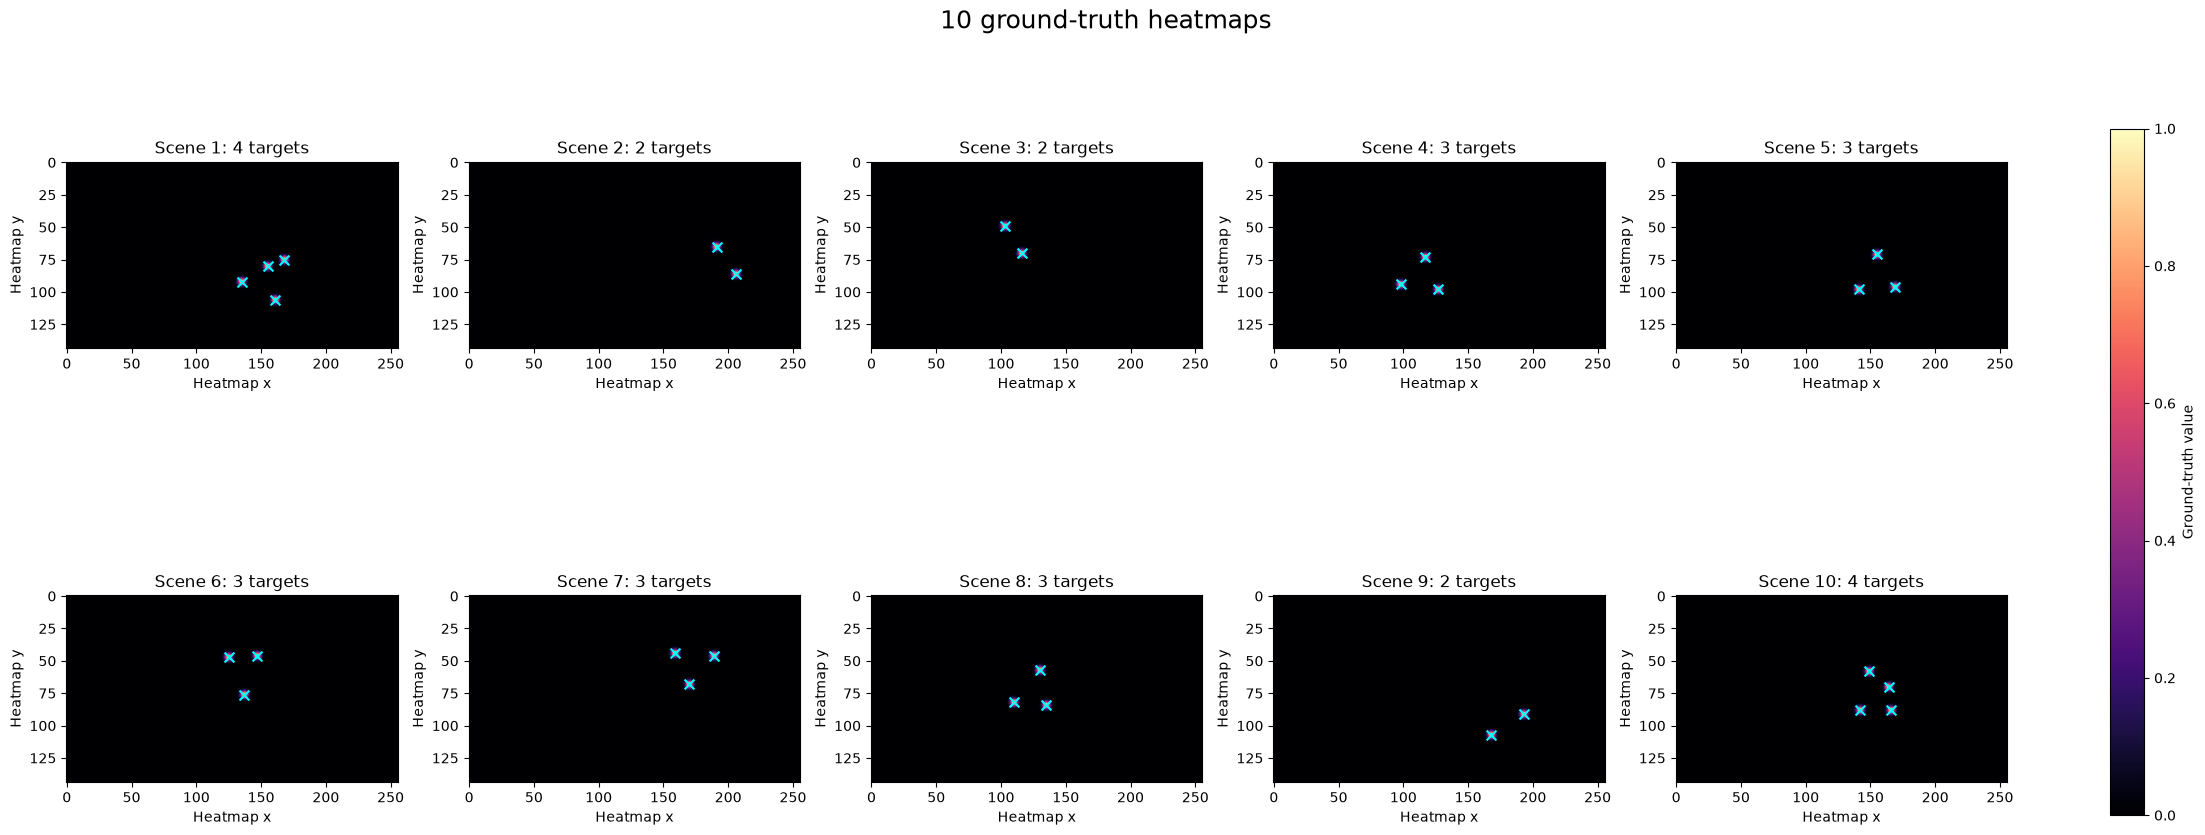

In [4]:
MINIMUM_PEAK_PROBABILITY = 0.05


def select_separated_peaks(
    heatmap,
    number_of_peaks,
    minimum_distance=5,
    minimum_probability=MINIMUM_PEAK_PROBABILITY,
):
    local_maximum_mask = heatmap == maximum_filter(
        heatmap,
        size=2 * minimum_distance + 1,
        mode="nearest",
    )
    candidate_mask = local_maximum_mask & (heatmap >= minimum_probability)
    candidate_coordinates = np.argwhere(candidate_mask)
    candidate_scores = heatmap[candidate_mask]
    score_order = np.argsort(candidate_scores)[::-1]
    return candidate_coordinates[score_order[:number_of_peaks]]


evaluation_results = []

for scene_index, record in enumerate(scene_records):
    target_centers_yx = np.argwhere(np.isclose(target_heatmaps[scene_index], 1.0))
    predicted_peaks_yx = select_separated_peaks(
        predicted_heatmaps[scene_index],
        number_of_peaks=record["active_count"],
    )

    if len(predicted_peaks_yx) and len(target_centers_yx):
        pairwise_distances = np.linalg.norm(
            predicted_peaks_yx[:, None, :] - target_centers_yx[None, :, :],
            axis=2,
        )
        predicted_indices, target_indices = linear_sum_assignment(pairwise_distances)
        matched_distances = pairwise_distances[predicted_indices, target_indices]
    else:
        target_indices = np.array([], dtype=int)
        matched_distances = np.array([], dtype=float)

    evaluation_results.append({
        "target_centers": target_centers_yx,
        "predicted_peaks": predicted_peaks_yx,
        "matched_distances": matched_distances,
        "unmatched_targets": len(target_centers_yx) - len(target_indices),
    })

    mean_distance = matched_distances.mean() if len(matched_distances) else float("nan")
    worst_distance = matched_distances.max() if len(matched_distances) else float("nan")
    print(
        f"Scene {scene_index + 1:2d} | seed={record['seed']} | "
        f"targets={len(target_centers_yx)} | peaks={len(predicted_peaks_yx)} | "
        f"unmatched={len(target_centers_yx) - len(target_indices)} | "
        f"mean={mean_distance:.2f}px | worst={worst_distance:.2f}px"
    )


fig, axes = plt.subplots(2, 5, figsize=(22, 8), constrained_layout=True)
for scene_index, axis in enumerate(axes.ravel()):
    record = scene_records[scene_index]
    axis.imshow(record["rgb"])
    axis.set_title(
        f"Scene {scene_index + 1} | seed {record['seed']}\n"
        f"{record['active_count']} active foods"
    )
    axis.axis("off")
fig.suptitle("10 randomized RGB environments", fontsize=18)
plt.show()


fig, axes = plt.subplots(2, 5, figsize=(22, 9), constrained_layout=True)
for scene_index, axis in enumerate(axes.ravel()):
    result = evaluation_results[scene_index]
    prediction_image = axis.imshow(
        predicted_heatmaps[scene_index],
        cmap="magma",
        vmin=0.0,
        vmax=1.0,
    )
    peaks = result["predicted_peaks"]
    if len(peaks):
        axis.scatter(
            peaks[:, 1],
            peaks[:, 0],
            facecolors="none",
            edgecolors="cyan",
            s=55,
            linewidths=1.3,
        )
    mean_distance = (
        result["matched_distances"].mean()
        if len(result["matched_distances"])
        else float("nan")
    )
    axis.set_title(
        f"Scene {scene_index + 1}: {len(peaks)} peaks\n"
        f"mean error {mean_distance:.2f}px"
    )
    axis.set_xlabel("Heatmap x")
    axis.set_ylabel("Heatmap y")
fig.colorbar(
    prediction_image,
    ax=axes.ravel().tolist(),
    shrink=0.8,
    label="Predicted probability",
)
fig.suptitle("10 best-generalized-U-Net predicted heatmaps", fontsize=18)
plt.show()


fig, axes = plt.subplots(2, 5, figsize=(22, 9), constrained_layout=True)
for scene_index, axis in enumerate(axes.ravel()):
    result = evaluation_results[scene_index]
    target_image = axis.imshow(
        target_heatmaps[scene_index],
        cmap="magma",
        vmin=0.0,
        vmax=1.0,
    )
    centers = result["target_centers"]
    if len(centers):
        axis.scatter(
            centers[:, 1],
            centers[:, 0],
            c="cyan",
            marker="x",
            s=50,
        )
    axis.set_title(f"Scene {scene_index + 1}: {len(centers)} targets")
    axis.set_xlabel("Heatmap x")
    axis.set_ylabel("Heatmap y")
fig.colorbar(
    target_image,
    ax=axes.ravel().tolist(),
    shrink=0.8,
    label="Ground-truth value",
)
fig.suptitle("10 ground-truth heatmaps", fontsize=18)
plt.show()